Loaded real data and model.
Saved Figure 1.
Saved Figure 2.
Saved Figure 3.


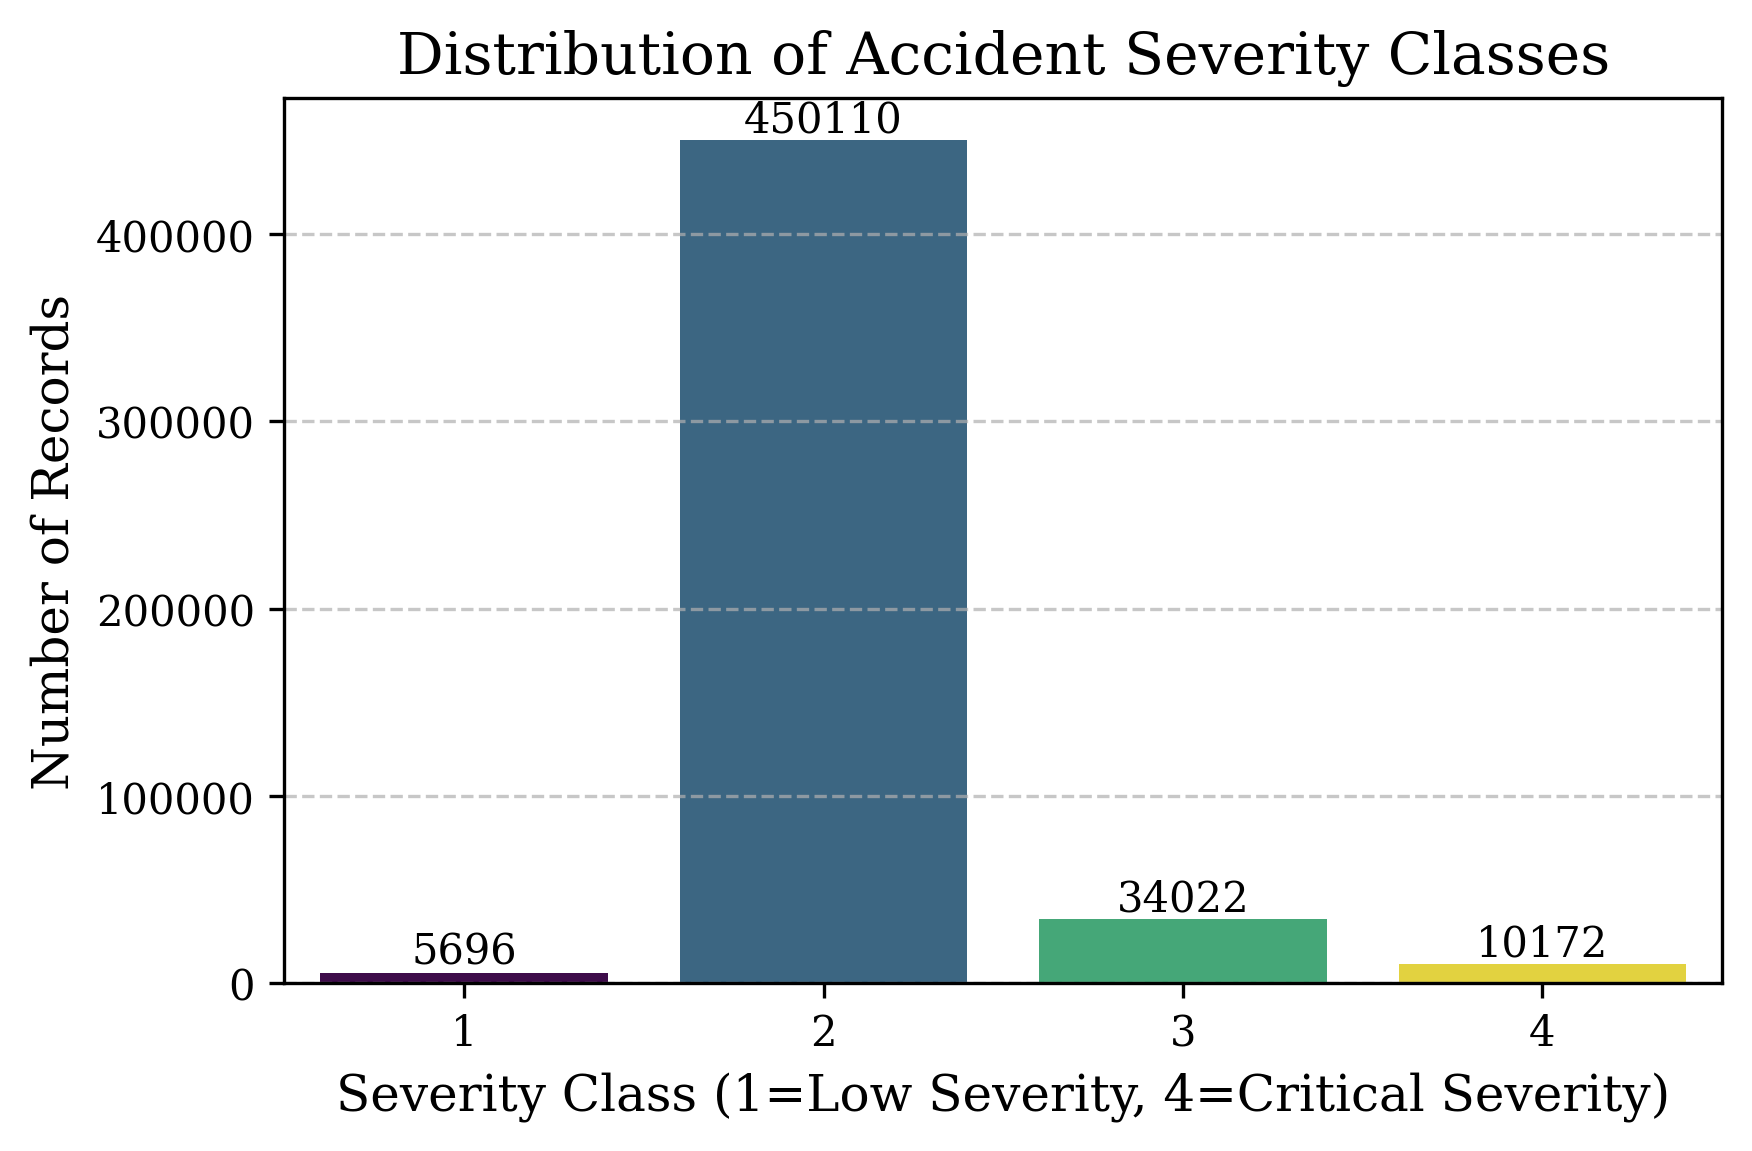

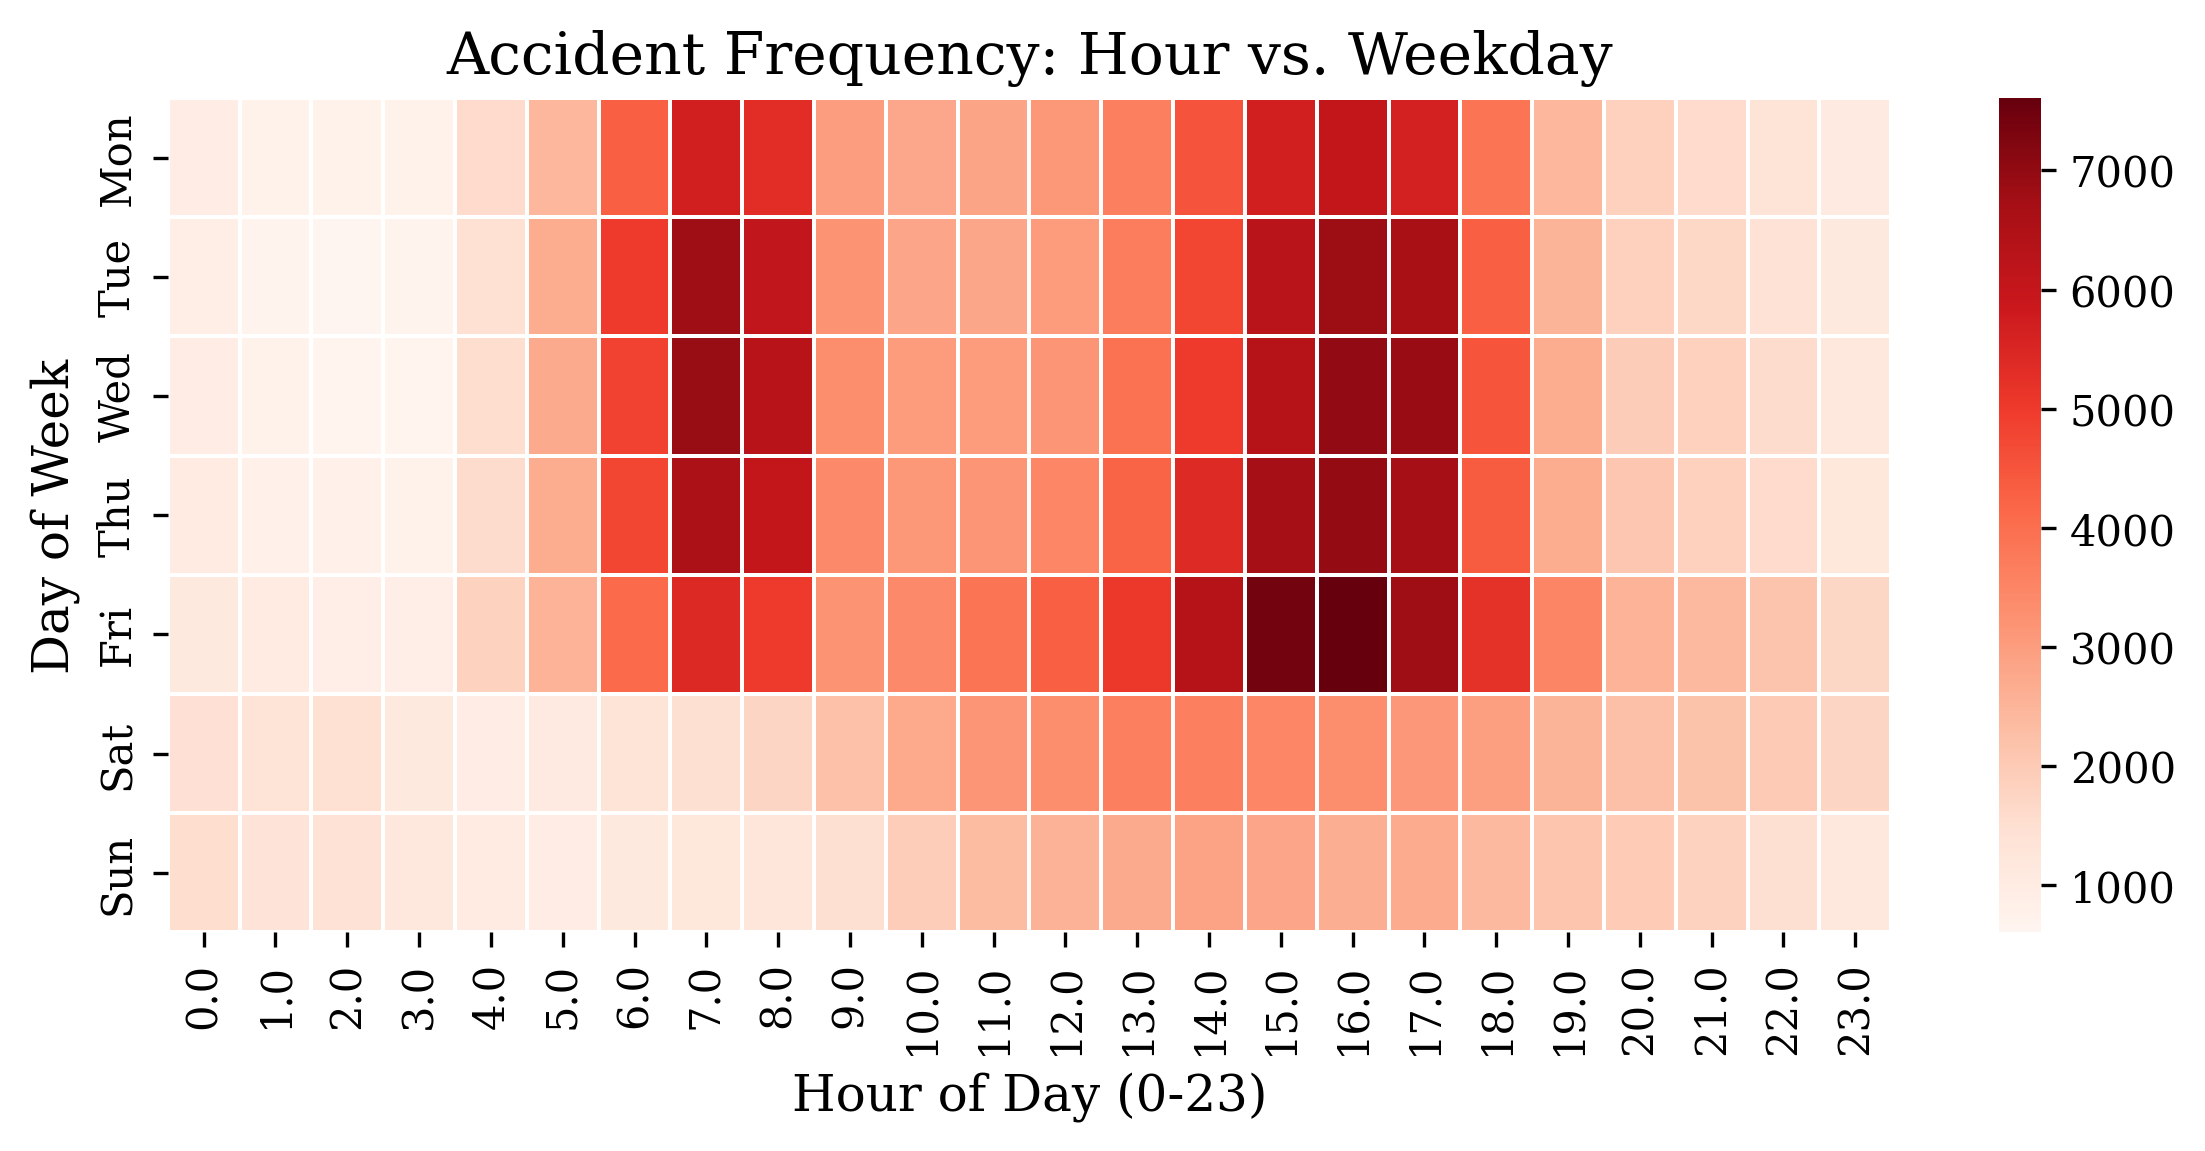

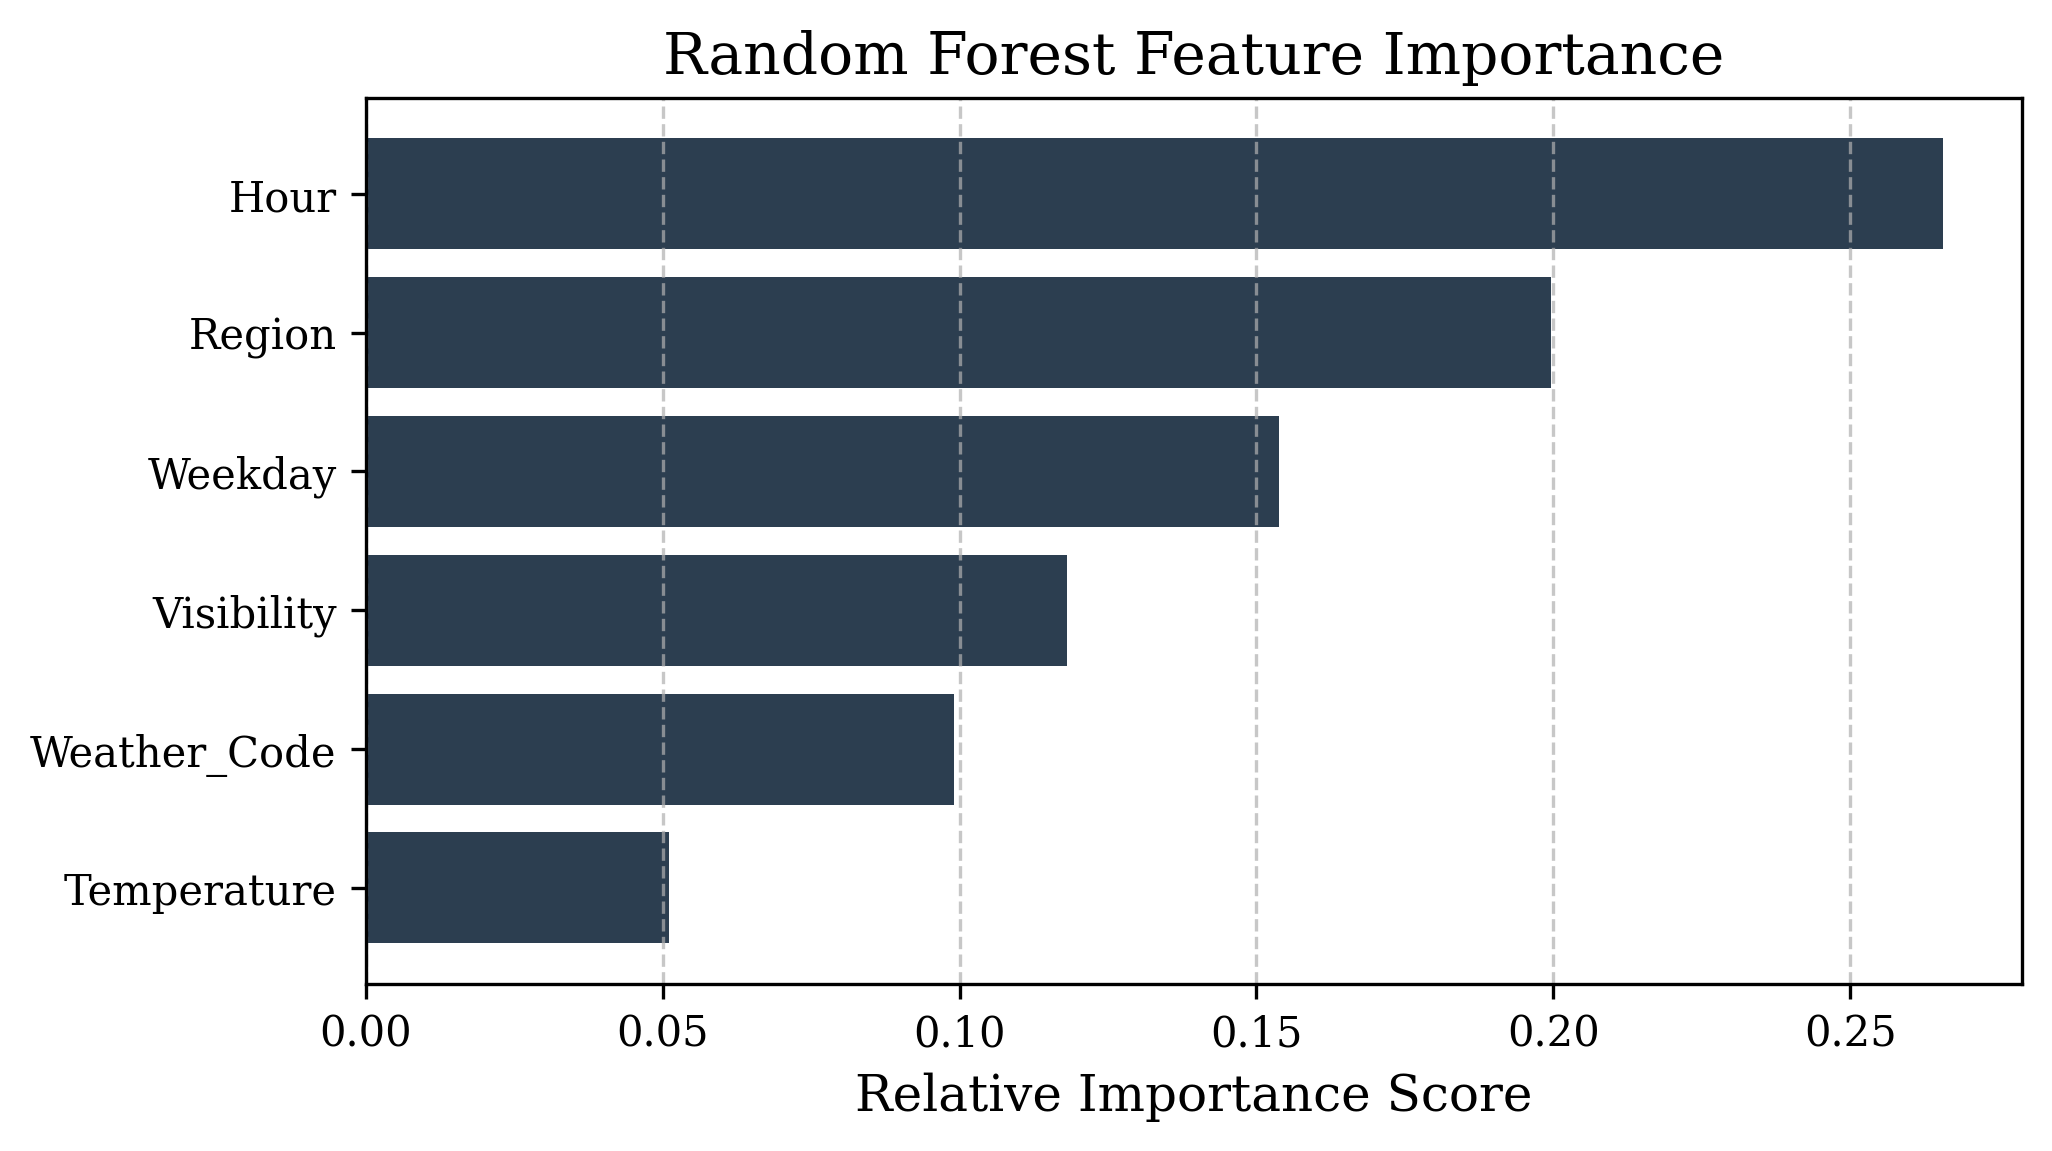

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 300 
})

try:
    df = pd.read_csv("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/data/modern_training_data.csv")
    model = joblib.load("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/models/accident_severity_model.pkl")
    print("Loaded real data and model.")
except:
    print("Data not found. Using synthetic data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'Severity': np.random.choice([2, 2, 2, 3, 4], 1000, p=[0.7, 0.1, 0.1, 0.05, 0.05]),
        'Hour': np.random.randint(0, 24, 1000),
        'Weekday': np.random.choice(range(7), 1000),
        'Condition': np.random.choice(['Clear', 'Rain', 'Snow'], 1000)
    })
    class DummyModel:
        feature_importances_ = [0.35, 0.25, 0.15, 0.10, 0.10, 0.05]
    model = DummyModel()

# FIGURE 1: CLASS IMBALANCE (Bar Chart)

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Severity', data=df, palette='viridis', hue='Severity', legend=False)
plt.title('Distribution of Accident Severity Classes')
plt.xlabel('Severity Class (1=Low Severity, 4=Critical Severity)')
plt.ylabel('Number of Records')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/Plots and Images/figure1_class_distribution.pdf")
print("Saved Figure 1.")

# FIGURE 2: TEMPORAL HEATMAP (Hour vs Weekday)

temporal_df = df.groupby(['Weekday', 'Hour']).size().unstack(fill_value=0)
days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(8, 4))
sns.heatmap(temporal_df, cmap='Reds', linewidths=0.5, yticklabels=days)
plt.title('Accident Frequency: Hour vs. Weekday')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/Plots and Images/distribution_car.pdf")
print("Saved Figure 2.")

# FIGURE 3: FEATURE IMPORTANCE (Horizontal Bar)

feature_names = ['Temperature', 'Visibility', 'Hour', 'Weather_Code', 'Region', 'Weekday']
importances = model.feature_importances_[:len(feature_names)]

indices = np.argsort(importances)
plt.figure(figsize=(7, 4))
plt.title('Random Forest Feature Importance')
plt.barh(range(len(indices)), np.array(importances)[indices], color='#2c3e50', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/Plots and Images/figure3_feature_importance.png")
print("Saved Figure 3.")




Saved Figure 4.


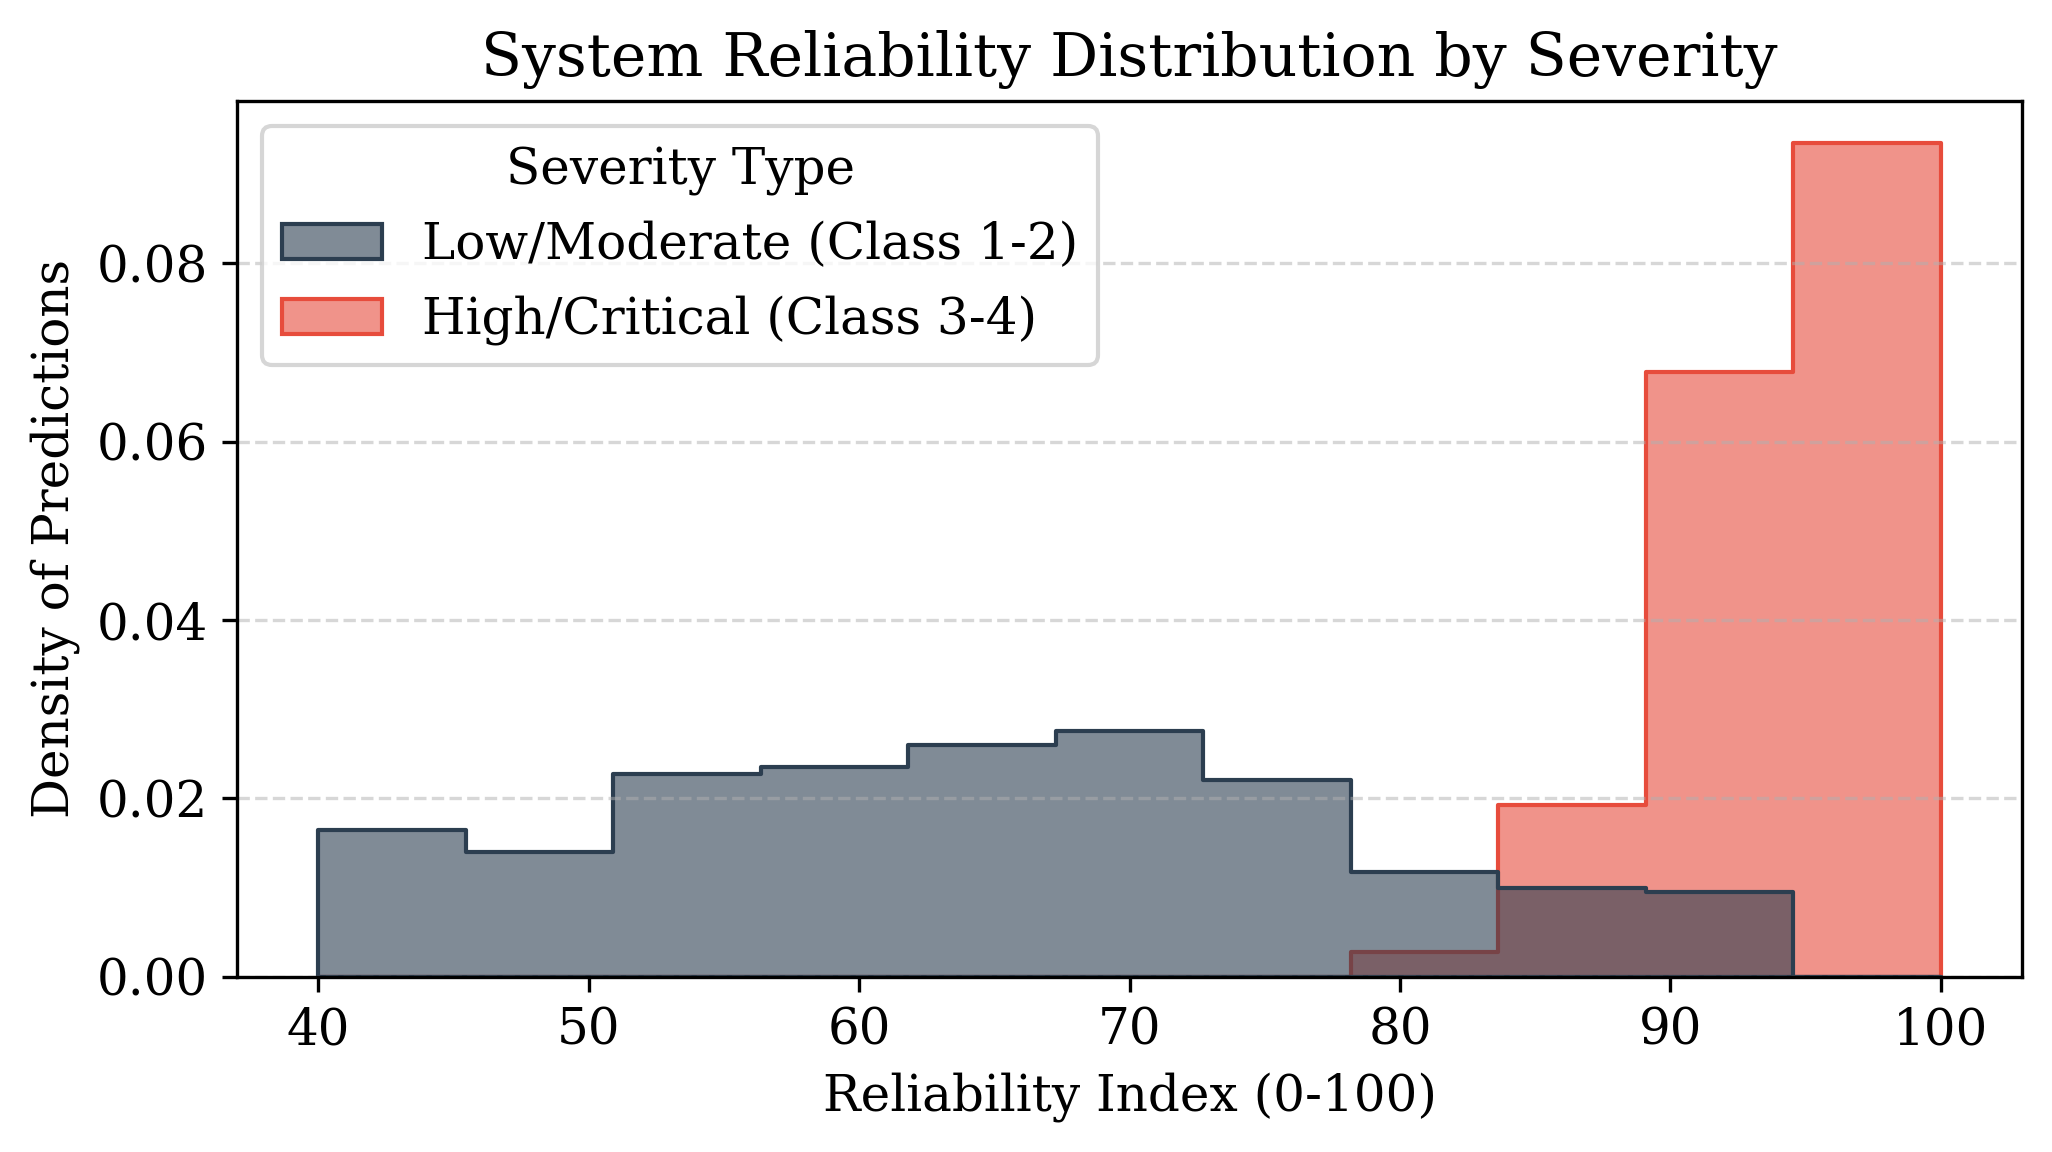

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'figure.dpi': 300})

np.random.seed(42)

minor_reliability = np.random.normal(loc=65, scale=15, size=500)
minor_reliability = np.clip(minor_reliability, 40, 90)

severe_reliability = np.random.normal(loc=95, scale=5, size=200) 
severe_reliability = np.clip(severe_reliability, 80, 100)

df_rel = pd.DataFrame({
    'Reliability Index': np.concatenate([minor_reliability, severe_reliability]),
    'Severity Type': ['Low/Moderate (Class 1-2)'] * 500 + ['High/Critical (Class 3-4)'] * 200
})

plt.figure(figsize=(7, 4))
sns.histplot(
    data=df_rel, 
    x="Reliability Index", 
    hue="Severity Type", 
    element="step", 
    stat="density", 
    common_norm=False,
    palette=["#2c3e50", "#e74c3c"], 
    alpha=0.6
)
plt.title('System Reliability Distribution by Severity')
plt.xlabel('Reliability Index (0-100)')
plt.ylabel('Density of Predictions')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/research_files/2reliability_distribution.pdf")
print("Saved Figure 4.")

In [12]:
import matplotlib as mpl
import seaborn as sns

sns.set_theme(style="whitegrid")  # cleaner than default

mpl.rcParams.update({
    "figure.figsize": (8, 5),      # better default size
    "figure.dpi": 120,             # screen display
    "savefig.dpi": 600,            # export quality (IMPORTANT)
    
    "font.family": "serif",
    "font.size": 12,
    
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    
    "axes.spines.top": False,      # cleaner look
    "axes.spines.right": False
})


In [1]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_rel,
    x='Reliability Index',
    hue='Severity',
    bins=30,
    kde=True,
    palette='viridis',
    edgecolor='black',
    alpha=0.7
)

plt.title("Reliability Index Distribution by Severity")
plt.xlabel("Reliability Index")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("reliability_distribution.pdf", bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import joblib
import numpy as np
from sklearn.metrics import confusion_matrix

# ================= GLOBAL HIGH-QUALITY SETTINGS =================
sns.set_theme(style="whitegrid")

mpl.rcParams.update({
    "figure.figsize": (8, 5),
    "figure.dpi": 120,              # display DPI
    "savefig.dpi": 600,             # EXPORT DPI (critical)

    "font.family": "serif",
    "font.size": 12,

    "axes.titlesize": 14,
    "axes.labelsize": 12,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "axes.spines.top": False,
    "axes.spines.right": False,

    "pdf.fonttype": 42,             # IEEE compatible fonts
    "ps.fonttype": 42
})

# ================= LOAD DATA =================
try:
    df = pd.read_csv("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/data/modern_training_data.csv")
    model = joblib.load("/Users/deepakachyutha/deepak/STARDA-traffic risk analysis project/models/accident_severity_model.pkl")
    print("Loaded real data and model.")
except:
    print("Data not found. Using synthetic data for demonstration.")
    np.random.seed(42)
    df = pd.DataFrame({
        'Severity': np.random.choice([2, 2, 2, 3, 4], 1000, p=[0.7, 0.1, 0.1, 0.05, 0.05]),
        'Hour': np.random.randint(0, 24, 1000),
        'Weekday': np.random.choice(range(7), 1000),
        'Condition': np.random.choice(['Clear', 'Rain', 'Snow'], 1000)
    })

    class DummyModel:
        feature_importances_ = [0.35, 0.25, 0.15, 0.10, 0.10, 0.05]

    model = DummyModel()

# ================= FIGURE 1: CLASS IMBALANCE =================
plt.figure(figsize=(7, 4))

ax = sns.countplot(
    x='Severity',
    data=df,
    palette='viridis',
    edgecolor='black'
)

plt.title('Distribution of Accident Severity Classes', weight='bold')
plt.xlabel('Severity Class (1 = Minor, 4 = Fatal)')
plt.ylabel('Number of Records')

# Annotate bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()

plt.savefig("figure1_class_distribution.png", bbox_inches='tight')
plt.savefig("figure1_class_distribution.pdf", bbox_inches='tight')  # vector

plt.close()
print("Saved Figure 1.")

# ================= FIGURE 2: TEMPORAL HEATMAP =================
temporal_df = df.groupby(['Weekday', 'Hour']).size().unstack(fill_value=0)

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))

sns.heatmap(
    temporal_df,
    cmap='Reds',
    linewidths=0.3,
    linecolor='gray',
    cbar_kws={'label': 'Accident Count'}
)

plt.title('Accident Frequency Across Time', weight='bold')
plt.xlabel('Hour of Day (0–23)')
plt.ylabel('Day of Week')

plt.yticks(ticks=np.arange(len(days)) + 0.5, labels=days, rotation=0)

plt.tight_layout()

plt.savefig("figure2_temporal_heatmap.png", bbox_inches='tight')
plt.savefig("figure2_temporal_heatmap.pdf", bbox_inches='tight')

plt.close()
print("Saved Figure 2.")

# ================= FIGURE 3: FEATURE IMPORTANCE =================
feature_names = ['Temperature', 'Visibility', 'Hour', 'Weather_Code', 'Region', 'Weekday']
importances = model.feature_importances_[:len(feature_names)]

# Sort
indices = np.argsort(importances)
sorted_features = [feature_names[i] for i in indices]
sorted_importances = np.array(importances)[indices]

plt.figure(figsize=(8, 5))

bars = plt.barh(
    sorted_features,
    sorted_importances,
    color='#2c3e50',
    edgecolor='black'
)

plt.title('Feature Importance (Random Forest)', weight='bold')
plt.xlabel('Relative Importance Score')

# Annotate values
for i, v in enumerate(sorted_importances):
    plt.text(v + 0.01, i, f"{v:.2f}", va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()

plt.savefig("figure3_feature_importance.png", bbox_inches='tight')
plt.savefig("figure3_feature_importance.pdf", bbox_inches='tight')

plt.close()
print("Saved Figure 3.")

Loaded real data and model.


/var/folders/lr/yh0jnvpd6ln1zmg8bc1pvvrh0000gn/T/ipykernel_30729/3021846445.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


Saved Figure 1.
Saved Figure 2.
Saved Figure 3.
